EMT columns: Index(['time', 'PrefConverter1', 'PrefConverter2', 'QrefConverter1',
       'QrefConverter2', 'fInfeed', 'iInfeed_0', 'iInfeed_1', 'iInfeed_2',
       'iLine1_0', 'iLine1_1', 'iLine1_2', 'iLine2_0', 'iLine2_1', 'iLine2_2',
       'iLoad1_0', 'iLoad1_1', 'iLoad1_2', 'iLoad2_0', 'iLoad2_1', 'iLoad2_2',
       'idConverter1', 'idConverter2', 'iqConverter1', 'iqConverter2',
       'vConverter1_0', 'vConverter1_1', 'vConverter1_2', 'vConverter2_0',
       'vConverter2_1', 'vConverter2_2', 'vInfeed_0', 'vInfeed_1', 'vInfeed_2',
       'vLoad_0', 'vLoad_1', 'vLoad_2', 'vdConverter1', 'vdConverter2',
       'vqConverter1', 'vqConverter2'],
      dtype='object')
DP columns: Index(['time', 'PrefConverter1', 'PrefConverter2', 'QrefConverter1',
       'QrefConverter2', 'fInfeed', 'iInfeed.im', 'iInfeed.re', 'iLine1.im',
       'iLine1.re', 'iLine2.im', 'iLine2.re', 'iLoad1.im', 'iLoad1.re',
       'iLoad2.im', 'iLoad2.re', 'idConverter1', 'idConverter2',
       'iqConverter1', 'iqConv

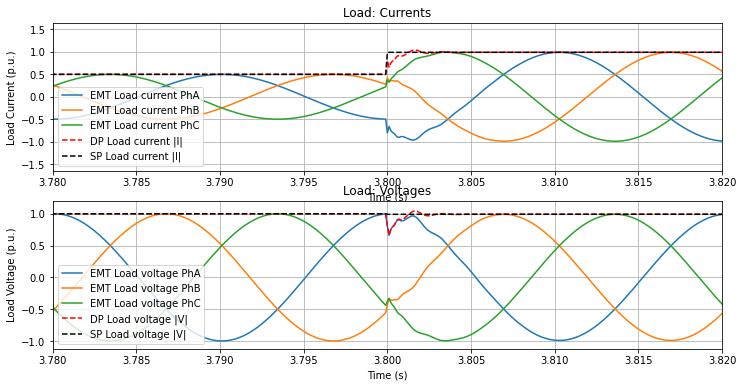

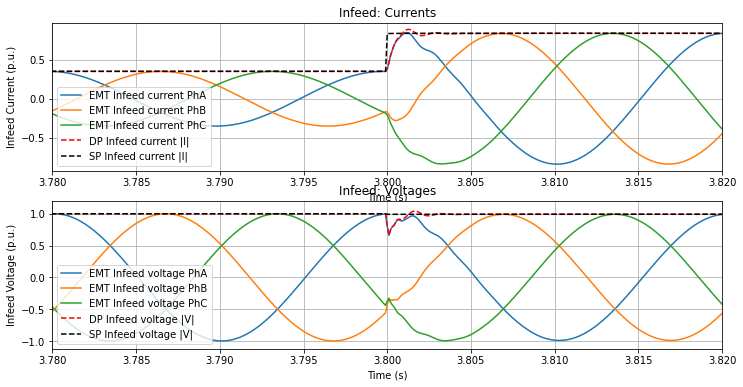

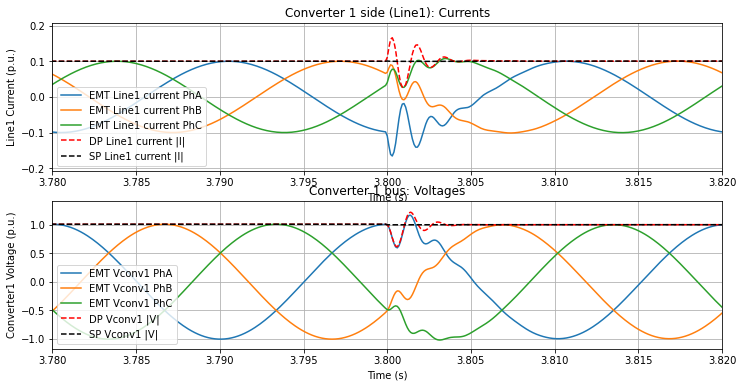

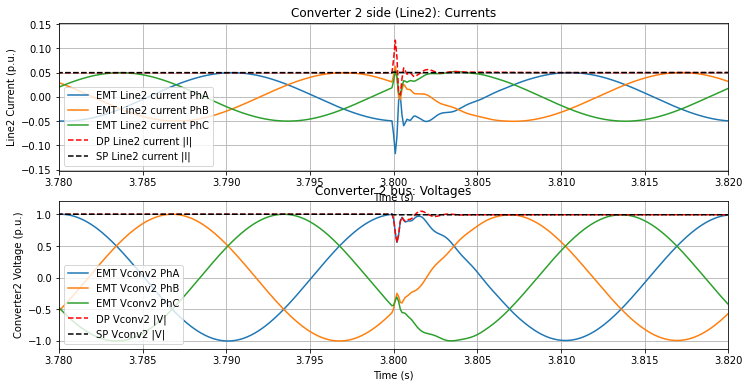

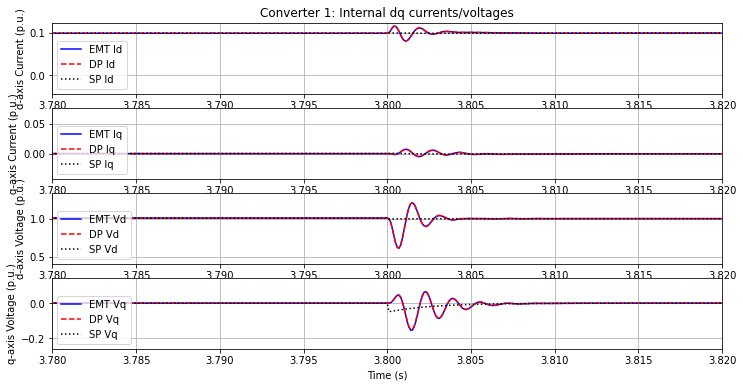

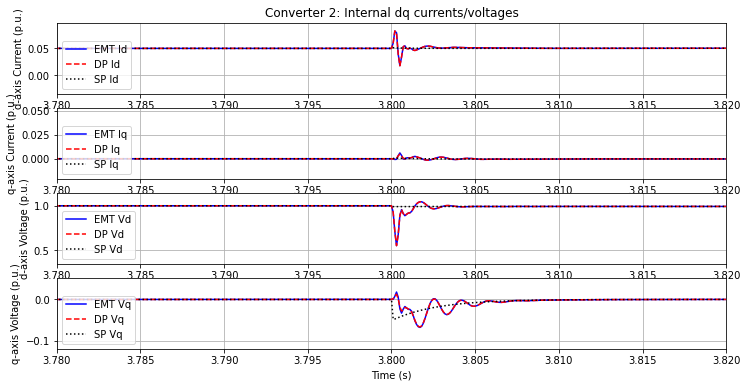

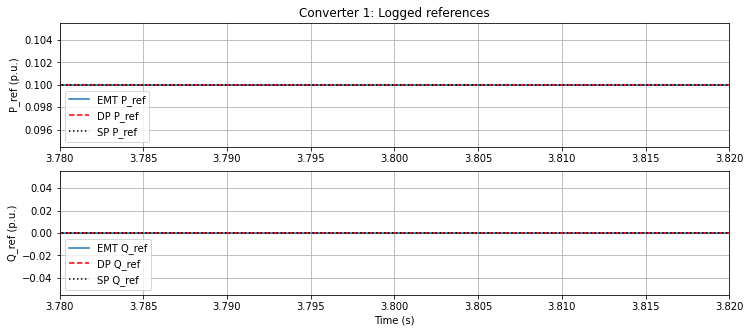

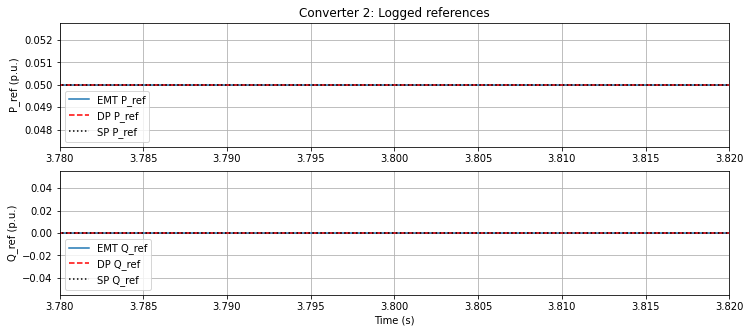

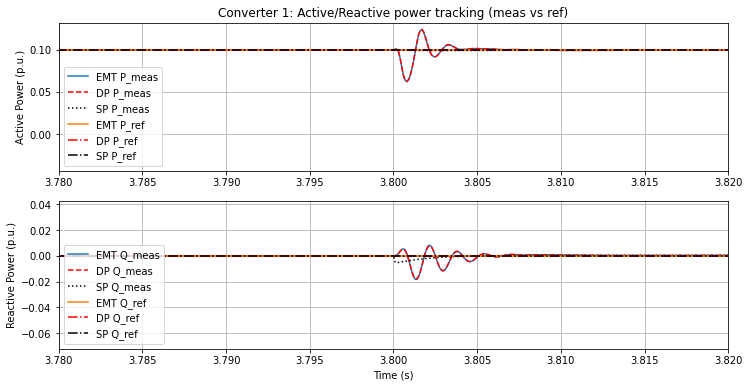

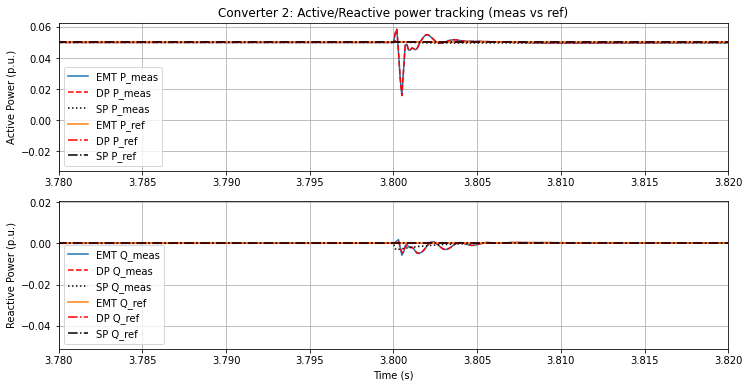

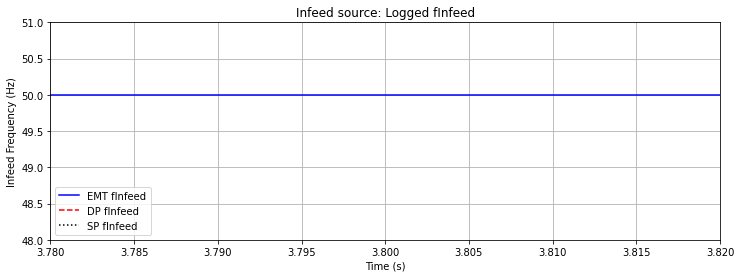

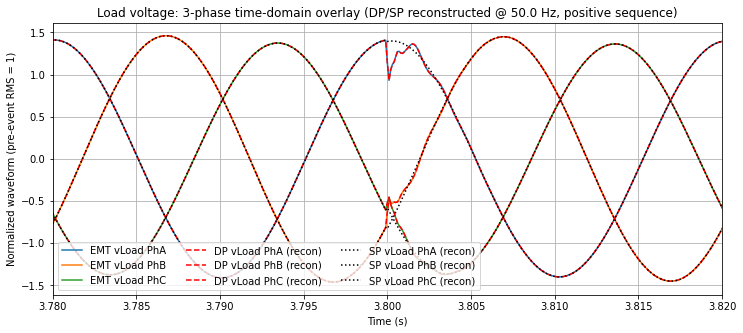

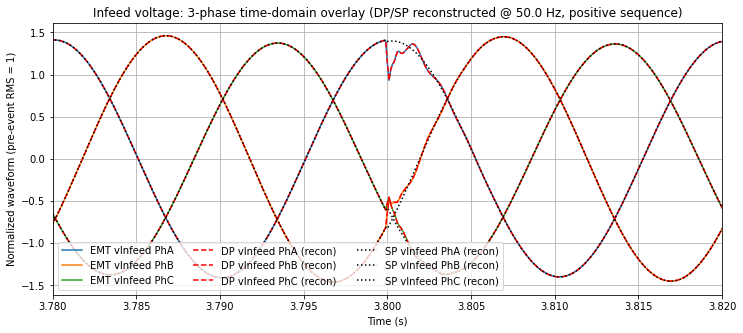

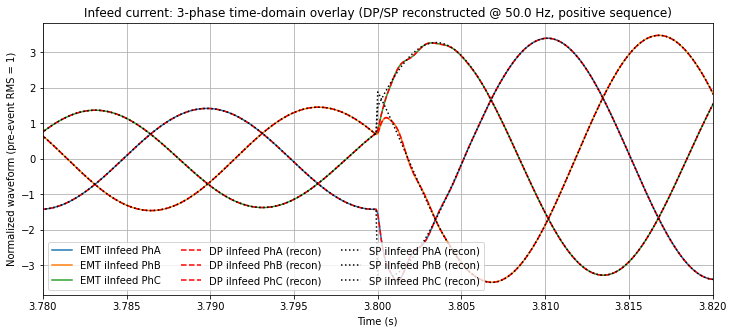

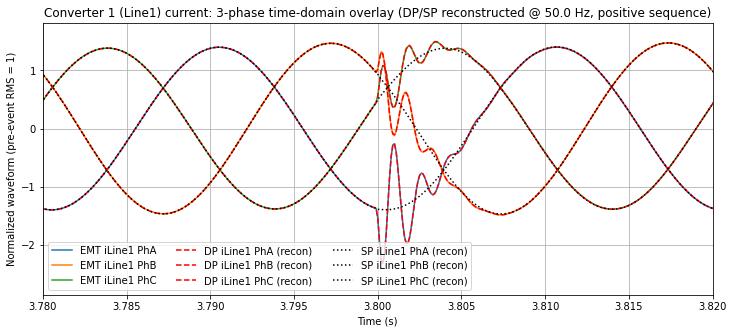

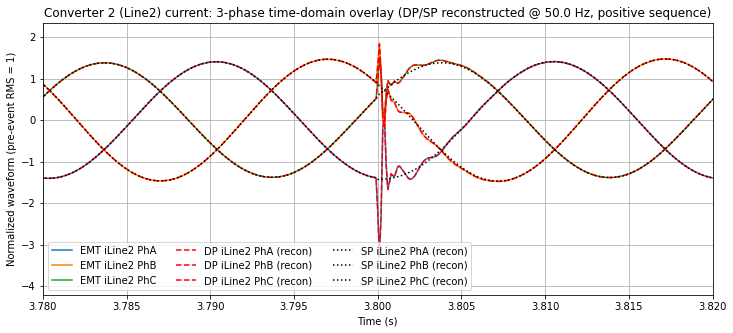

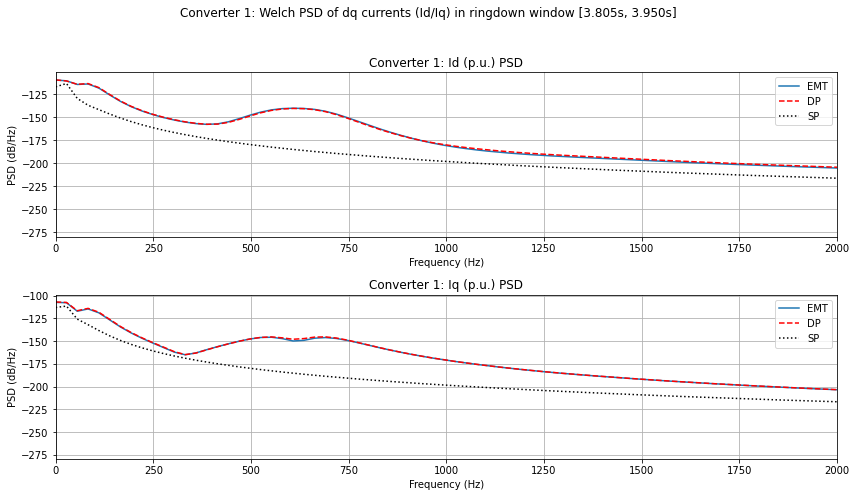

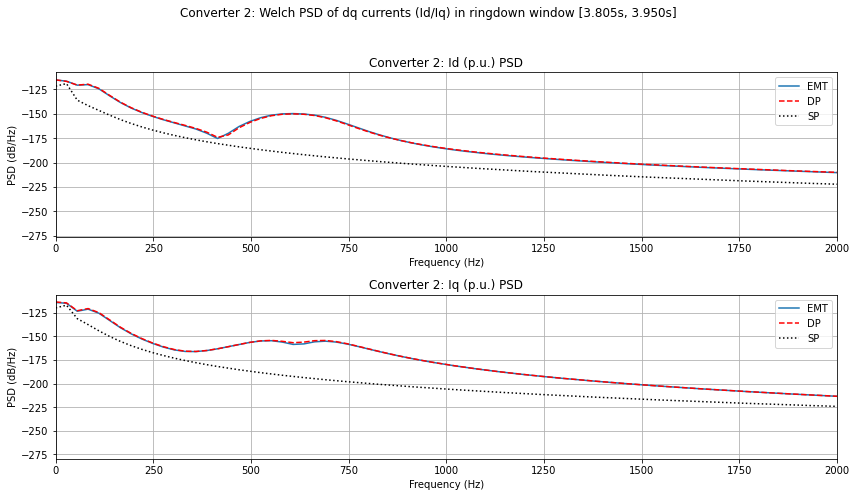

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SciPy (allowed)
from scipy import signal
from scipy.optimize import curve_fit

# ----------------------------
# User-tunable globals
# ----------------------------
NOMINAL_FREQ_HZ = 50.0                 # DP/SP reconstruction carrier
EVENT_TIME_S    = 3.8                  # for summaries / normalization
PLOT_XLIM       = (3.78, 3.82)         # GLOBAL plotted time window

# Pre-event window used for normalizing reconstructed waveforms (helps overlay scaling)
PRE_EVENT_NORM_WINDOW = (EVENT_TIME_S - 0.05, EVENT_TIME_S - 0.005)

# Frequency axis limits for PSD plots
PSD_XLIM_HZ = (0, 2000)

# ----------------------------
# 1) Load data
# ----------------------------
def load_data(path_EMT, path_DP, path_SP):
    df_EMT = pd.read_csv(path_EMT)
    df_DP  = pd.read_csv(path_DP)
    df_SP  = pd.read_csv(path_SP)

    df_EMT.columns = df_EMT.columns.str.strip()
    df_DP.columns  = df_DP.columns.str.strip()
    df_SP.columns  = df_SP.columns.str.strip()

    print("EMT columns:", df_EMT.columns)
    print("DP columns:", df_DP.columns)
    print("SP columns:", df_SP.columns)

    return df_EMT, df_DP, df_SP

# ----------------------------
# 2) Compute base parameters
# ----------------------------
def compute_base_values():
    baseVoltageLineToLine   = 110e3
    basePowerThreePhase     = 100e6
    baseCurrent             = basePowerThreePhase / baseVoltageLineToLine / np.sqrt(3)
    return baseCurrent, baseVoltageLineToLine

def compute_base_values_inverter():
    baseVoltageLineToLine   = 1500
    basePowerThreePhase     = 100e6
    baseCurrent             = basePowerThreePhase / baseVoltageLineToLine / np.sqrt(3)
    baseCurrent             = baseCurrent * np.sqrt(3)  # account for Park transformation
    return baseCurrent, baseVoltageLineToLine

def compute_base_power():
    return 100e6

# Helper: pick the first existing column name
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ----------------------------
# DP/SP phasor helpers + 3-phase reconstruction (positive sequence)
# ----------------------------
def get_complex_phasor(df, base_name):
    re_col = pick_col(df, [f"{base_name}.re", f"{base_name}_re", f"{base_name}.real"])
    im_col = pick_col(df, [f"{base_name}.im", f"{base_name}_im", f"{base_name}.imag"])
    if re_col is None or im_col is None:
        return None
    return df[re_col].to_numpy() + 1j * df[im_col].to_numpy()

def reconstruct_abc_from_phasor(t, X, freq_hz=NOMINAL_FREQ_HZ, rms_phasor=True):
    """
    Reconstruct 3-phase time-domain waveforms from a single complex phasor X(t)
    assuming positive sequence:
        Va = Re{ X * exp(j*w*t) }
        Vb = Re{ X * exp(j*(w*t - 120deg)) }
        Vc = Re{ X * exp(j*(w*t + 120deg)) }

    If X is RMS phasor, multiply by sqrt(2) to obtain peak waveform.
    """
    if X is None:
        return None, None, None
    scale = np.sqrt(2) if rms_phasor else 1.0
    wt = 2 * np.pi * freq_hz * t
    shift_b = -2 * np.pi / 3
    shift_c = +2 * np.pi / 3
    va = scale * np.real(X * np.exp(1j * (wt + 0.0)))
    vb = scale * np.real(X * np.exp(1j * (wt + shift_b)))
    vc = scale * np.real(X * np.exp(1j * (wt + shift_c)))
    return va, vb, vc

def rms_in_window(t, x, t0, t1):
    m = (t >= t0) & (t <= t1)
    if np.sum(m) < 5:
        return None
    return np.sqrt(np.mean(x[m] ** 2))

def normalize_by_pre_event_rms(t, x, window=PRE_EVENT_NORM_WINDOW):
    r = rms_in_window(t, x, window[0], window[1])
    if r is None or r <= 0:
        return x
    return x / r

def plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, signal_base, equipment_label,
                                  freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True):
    """
    Time-domain overlay for all 3 phases in ONE plot:
      EMT: uses *_0,_1,_2 instantaneous
      DP/SP: reconstructs abc from single phasor assuming positive sequence
    """
    t_emt = df_EMT["time"].to_numpy()
    t_dp  = df_DP["time"].to_numpy()
    t_sp  = df_SP["time"].to_numpy()

    ca, cb, cc = f"{signal_base}_0", f"{signal_base}_1", f"{signal_base}_2"
    if not all(c in df_EMT.columns for c in [ca, cb, cc]):
        print(f"[WARN] EMT missing abc columns for {signal_base} ({equipment_label}): {ca},{cb},{cc}")
        return

    emt_a = df_EMT[ca].to_numpy()
    emt_b = df_EMT[cb].to_numpy()
    emt_c = df_EMT[cc].to_numpy()

    X_dp = get_complex_phasor(df_DP, signal_base)
    X_sp = get_complex_phasor(df_SP, signal_base)
    if X_dp is None or X_sp is None:
        print(f"[WARN] DP/SP missing phasor columns for {signal_base} ({equipment_label}).")
        return

    dp_a, dp_b, dp_c = reconstruct_abc_from_phasor(t_dp, X_dp, freq_hz=freq_hz, rms_phasor=True)
    sp_a, sp_b, sp_c = reconstruct_abc_from_phasor(t_sp, X_sp, freq_hz=freq_hz, rms_phasor=True)

    if normalize:
        emt_a = normalize_by_pre_event_rms(t_emt, emt_a)
        emt_b = normalize_by_pre_event_rms(t_emt, emt_b)
        emt_c = normalize_by_pre_event_rms(t_emt, emt_c)
        dp_a  = normalize_by_pre_event_rms(t_dp,  dp_a)
        dp_b  = normalize_by_pre_event_rms(t_dp,  dp_b)
        dp_c  = normalize_by_pre_event_rms(t_dp,  dp_c)
        sp_a  = normalize_by_pre_event_rms(t_sp,  sp_a)
        sp_b  = normalize_by_pre_event_rms(t_sp,  sp_b)
        sp_c  = normalize_by_pre_event_rms(t_sp,  sp_c)
        ylab = "Normalized waveform (pre-event RMS = 1)"
    else:
        ylab = "Instantaneous waveform (native units)"

    plt.figure(figsize=(12, 5))
    plt.grid(True)
    plt.title(f"{equipment_label}: 3-phase time-domain overlay (DP/SP reconstructed @ {freq_hz} Hz, positive sequence)")

    plt.plot(t_emt, emt_a, label=f"EMT {signal_base} PhA")
    plt.plot(t_emt, emt_b, label=f"EMT {signal_base} PhB")
    plt.plot(t_emt, emt_c, label=f"EMT {signal_base} PhC")

    plt.plot(t_dp, dp_a, "r--", label=f"DP {signal_base} PhA (recon)")
    plt.plot(t_dp, dp_b, "r--", label=f"DP {signal_base} PhB (recon)")
    plt.plot(t_dp, dp_c, "r--", label=f"DP {signal_base} PhC (recon)")

    plt.plot(t_sp, sp_a, "k:", label=f"SP {signal_base} PhA (recon)")
    plt.plot(t_sp, sp_b, "k:", label=f"SP {signal_base} PhB (recon)")
    plt.plot(t_sp, sp_c, "k:", label=f"SP {signal_base} PhC (recon)")

    plt.xlabel("Time (s)")
    plt.ylabel(ylab)
    plt.xlim(*xlim)
    plt.legend(loc="lower left", ncol=3)

# ----------------------------
# Equipment plots (using global PLOT_XLIM)
# ----------------------------
def plot_load(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM):
    plt.figure(1, figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    EMT_load_I0 = (df_EMT['iLoad1_0'] + df_EMT['iLoad2_0']) / baseCurrent / np.sqrt(2)
    EMT_load_I1 = (df_EMT['iLoad1_1'] + df_EMT['iLoad2_1']) / baseCurrent / np.sqrt(2)
    EMT_load_I2 = (df_EMT['iLoad1_2'] + df_EMT['iLoad2_2']) / baseCurrent / np.sqrt(2)
    plt.plot(df_EMT['time'], EMT_load_I0, label='EMT Load current PhA')
    plt.plot(df_EMT['time'], EMT_load_I1, label='EMT Load current PhB')
    plt.plot(df_EMT['time'], EMT_load_I2, label='EMT Load current PhC')

    Iload_DP = np.abs((df_DP['iLoad1.re'] + df_DP['iLoad2.re']) + 1j*(df_DP['iLoad1.im'] + df_DP['iLoad2.im'])) / baseCurrent / np.sqrt(3)
    Iload_SP = np.abs((df_SP['iLoad1.re'] + df_SP['iLoad2.re']) + 1j*(df_SP['iLoad1.im'] + df_SP['iLoad2.im'])) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], Iload_DP, 'r--', label='DP Load current |I|')
    plt.plot(df_SP['time'], Iload_SP, 'k--', label='SP Load current |I|')
    plt.xlabel('Time (s)')
    plt.ylabel('Load Current (p.u.)')
    plt.xlim(*xlim)
    plt.title("Load: Currents")
    plt.legend(loc='lower left')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    v0 = df_EMT['vLoad_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    v1 = df_EMT['vLoad_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    v2 = df_EMT['vLoad_2'] / baseVoltage * np.sqrt(3) / np.sqrt(2)
    plt.plot(df_EMT['time'], v0, label='EMT Load voltage PhA')
    plt.plot(df_EMT['time'], v1, label='EMT Load voltage PhB')
    plt.plot(df_EMT['time'], v2, label='EMT Load voltage PhC')

    Vload_DP = np.abs(df_DP['vLoad.re'] + 1j*df_DP['vLoad.im']) / baseVoltage
    Vload_SP = np.abs(df_SP['vLoad.re'] + 1j*df_SP['vLoad.im']) / baseVoltage
    plt.plot(df_DP['time'], Vload_DP, 'r--', label='DP Load voltage |V|')
    plt.plot(df_SP['time'], Vload_SP, 'k--', label='SP Load voltage |V|')
    plt.xlabel('Time (s)')
    plt.ylabel('Load Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.title("Load: Voltages")
    plt.legend(loc='lower left')

def plot_infeed(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM):
    plt.figure(2, figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], -df_EMT['iInfeed_0'] / baseCurrent / np.sqrt(2), label='EMT Infeed current PhA')
    plt.plot(df_EMT['time'], -df_EMT['iInfeed_1'] / baseCurrent / np.sqrt(2), label='EMT Infeed current PhB')
    plt.plot(df_EMT['time'], -df_EMT['iInfeed_2'] / baseCurrent / np.sqrt(2), label='EMT Infeed current PhC')

    Iinf_DP = np.abs(df_DP['iInfeed.re'] + 1j * df_DP['iInfeed.im']) / baseCurrent / np.sqrt(3)
    Iinf_SP = np.abs(df_SP['iInfeed.re'] + 1j * df_SP['iInfeed.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], Iinf_DP, 'r--', label='DP Infeed current |I|')
    plt.plot(df_SP['time'], Iinf_SP, 'k--', label='SP Infeed current |I|')
    plt.xlabel('Time (s)')
    plt.ylabel('Infeed Current (p.u.)')
    plt.xlim(*xlim)
    plt.title("Infeed: Currents")
    plt.legend(loc='lower left')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vInfeed_0']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Infeed voltage PhA')
    plt.plot(df_EMT['time'], df_EMT['vInfeed_1']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Infeed voltage PhB')
    plt.plot(df_EMT['time'], df_EMT['vInfeed_2']/baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Infeed voltage PhC')

    Vinf_DP = np.abs(df_DP['vInfeed.re'] + 1j * df_DP['vInfeed.im']) / baseVoltage
    Vinf_SP = np.abs(df_SP['vInfeed.re'] + 1j * df_SP['vInfeed.im']) / baseVoltage
    plt.plot(df_DP['time'], Vinf_DP, 'r--', label='DP Infeed voltage |V|')
    plt.plot(df_SP['time'], Vinf_SP, 'k--', label='SP Infeed voltage |V|')
    plt.xlabel('Time (s)')
    plt.ylabel('Infeed Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.title("Infeed: Voltages")
    plt.legend(loc='lower left')

def plot_converter1(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM):
    plt.figure(3, figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['iLine1_0'] / baseCurrent / np.sqrt(2), label='EMT Line1 current PhA')
    plt.plot(df_EMT['time'], df_EMT['iLine1_1'] / baseCurrent / np.sqrt(2), label='EMT Line1 current PhB')
    plt.plot(df_EMT['time'], df_EMT['iLine1_2'] / baseCurrent / np.sqrt(2), label='EMT Line1 current PhC')

    I1_DP = np.abs(df_DP['iLine1.re'] + 1j * df_DP['iLine1.im']) / baseCurrent / np.sqrt(3)
    I1_SP = np.abs(df_SP['iLine1.re'] + 1j * df_SP['iLine1.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], I1_DP, 'r--', label='DP Line1 current |I|')
    plt.plot(df_SP['time'], I1_SP, 'k--', label='SP Line1 current |I|')
    plt.xlabel('Time (s)')
    plt.ylabel('Line1 Current (p.u.)')
    plt.xlim(*xlim)
    plt.title("Converter 1 side (Line1): Currents")
    plt.legend(loc='lower left')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vConverter1_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv1 PhA')
    plt.plot(df_EMT['time'], df_EMT['vConverter1_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv1 PhB')
    plt.plot(df_EMT['time'], df_EMT['vConverter1_2'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv1 PhC')

    V1_DP = np.abs(df_DP['vConverter1.re'] + 1j * df_DP['vConverter1.im']) / baseVoltage
    V1_SP = np.abs(df_SP['vConverter1.re'] + 1j * df_SP['vConverter1.im']) / baseVoltage
    plt.plot(df_DP['time'], V1_DP, 'r--', label='DP Vconv1 |V|')
    plt.plot(df_SP['time'], V1_SP, 'k--', label='SP Vconv1 |V|')
    plt.xlabel('Time (s)')
    plt.ylabel('Converter1 Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.title("Converter 1 bus: Voltages")
    plt.legend(loc='lower left')

def plot_converter2(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM):
    plt.figure(4, figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['iLine2_0'] / baseCurrent / np.sqrt(2), label='EMT Line2 current PhA')
    plt.plot(df_EMT['time'], df_EMT['iLine2_1'] / baseCurrent / np.sqrt(2), label='EMT Line2 current PhB')
    plt.plot(df_EMT['time'], df_EMT['iLine2_2'] / baseCurrent / np.sqrt(2), label='EMT Line2 current PhC')

    I2_DP = np.abs(df_DP['iLine2.re'] + 1j * df_DP['iLine2.im']) / baseCurrent / np.sqrt(3)
    I2_SP = np.abs(df_SP['iLine2.re'] + 1j * df_SP['iLine2.im']) / baseCurrent / np.sqrt(3)
    plt.plot(df_DP['time'], I2_DP, 'r--', label='DP Line2 current |I|')
    plt.plot(df_SP['time'], I2_SP, 'k--', label='SP Line2 current |I|')
    plt.xlabel('Time (s)')
    plt.ylabel('Line2 Current (p.u.)')
    plt.xlim(*xlim)
    plt.title("Converter 2 side (Line2): Currents")
    plt.legend(loc='lower left')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['vConverter2_0'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv2 PhA')
    plt.plot(df_EMT['time'], df_EMT['vConverter2_1'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv2 PhB')
    plt.plot(df_EMT['time'], df_EMT['vConverter2_2'] / baseVoltage * np.sqrt(3) / np.sqrt(2), label='EMT Vconv2 PhC')

    V2_DP = np.abs(df_DP['vConverter2.re'] + 1j * df_DP['vConverter2.im']) / baseVoltage
    V2_SP = np.abs(df_SP['vConverter2.re'] + 1j * df_SP['vConverter2.im']) / baseVoltage
    plt.plot(df_DP['time'], V2_DP, 'r--', label='DP Vconv2 |V|')
    plt.plot(df_SP['time'], V2_SP, 'k--', label='SP Vconv2 |V|')
    plt.xlabel('Time (s)')
    plt.ylabel('Converter2 Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.title("Converter 2 bus: Voltages")
    plt.legend(loc='lower left')

def plot_converter_internal_vars(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, conv_idx, xlim=PLOT_XLIM):
    fig_num = 4 + conv_idx  # 5 for conv1, 6 for conv2
    plt.figure(fig_num, figsize=(12, 6))
    colors = {'EMT': 'blue', 'DP': 'red', 'SP': 'black'}

    id_col = f'idConverter{conv_idx}'
    iq_col = f'iqConverter{conv_idx}'
    vd_col = f'vdConverter{conv_idx}'
    vq_col = f'vqConverter{conv_idx}'

    plt.subplot(4, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT[id_col] / baseCurrent, label='EMT Id', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'],  df_DP[id_col]  / baseCurrent, label='DP Id',  linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'],  df_SP[id_col]  / baseCurrent, label='SP Id', linestyle=':', color=colors['SP'])
    plt.ylabel('d-axis Current (p.u.)')
    plt.xlim(*xlim)
    plt.title(f"Converter {conv_idx}: Internal dq currents/voltages")
    plt.legend(loc='lower left')

    plt.subplot(4, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT[iq_col] / baseCurrent, label='EMT Iq', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'],  df_DP[iq_col]  / baseCurrent, label='DP Iq',  linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'],  df_SP[iq_col]  / baseCurrent, label='SP Iq', linestyle=':', color=colors['SP'])
    plt.ylabel('q-axis Current (p.u.)')
    plt.xlim(*xlim)
    plt.legend(loc='lower left')

    plt.subplot(4, 1, 3)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT[vd_col] / baseVoltage, label='EMT Vd', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'],  df_DP[vd_col]  / baseVoltage, label='DP Vd',  linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'],  df_SP[vd_col]  / baseVoltage, label='SP Vd', linestyle=':', color=colors['SP'])
    plt.ylabel('d-axis Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.legend(loc='lower left')

    plt.subplot(4, 1, 4)
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT[vq_col] / baseVoltage, label='EMT Vq', linestyle='-', color=colors['EMT'])
    plt.plot(df_DP['time'],  df_DP[vq_col]  / baseVoltage, label='DP Vq',  linestyle='--', color=colors['DP'])
    plt.plot(df_SP['time'],  df_SP[vq_col]  / baseVoltage, label='SP Vq', linestyle=':', color=colors['SP'])
    plt.xlabel('Time (s)')
    plt.ylabel('q-axis Voltage (p.u.)')
    plt.xlim(*xlim)
    plt.legend(loc='lower left')

def plot_power_refs(df_EMT, df_DP, df_SP, basePowerThreePhase, conv_idx=1, xlim=PLOT_XLIM):
    plt.figure(7 + (conv_idx - 1), figsize=(12, 5))

    pref_name = f'PrefConverter{conv_idx}'
    qref_name = f'QrefConverter{conv_idx}'

    EMT_pref = pick_col(df_EMT, [pref_name, pref_name + ".re"])
    DP_pref  = pick_col(df_DP,  [pref_name, pref_name + ".re"])
    SP_pref  = pick_col(df_SP,  [pref_name, pref_name + ".re"])

    EMT_qref = pick_col(df_EMT, [qref_name, qref_name + ".re"])
    DP_qref  = pick_col(df_DP,  [qref_name, qref_name + ".re"])
    SP_qref  = pick_col(df_SP,  [qref_name, qref_name + ".re"])

    plt.subplot(2, 1, 1)
    plt.grid(True)
    if EMT_pref: plt.plot(df_EMT['time'], df_EMT[EMT_pref] / basePowerThreePhase, label='EMT P_ref')
    if DP_pref:  plt.plot(df_DP['time'],  df_DP[DP_pref]  / basePowerThreePhase, 'r--', label='DP P_ref')
    if SP_pref:  plt.plot(df_SP['time'],  df_SP[SP_pref]  / basePowerThreePhase, 'k:',  label='SP P_ref')
    plt.ylabel('P_ref (p.u.)')
    plt.xlim(*xlim)
    plt.title(f"Converter {conv_idx}: Logged references")
    plt.legend(loc='lower left')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    if EMT_qref: plt.plot(df_EMT['time'], df_EMT[EMT_qref] / basePowerThreePhase, label='EMT Q_ref')
    if DP_qref:  plt.plot(df_DP['time'],  df_DP[DP_qref]  / basePowerThreePhase, 'r--', label='DP Q_ref')
    if SP_qref:  plt.plot(df_SP['time'],  df_SP[SP_qref]  / basePowerThreePhase, 'k:',  label='SP Q_ref')
    plt.xlabel('Time (s)')
    plt.ylabel('Q_ref (p.u.)')
    plt.xlim(*xlim)
    plt.legend(loc='lower left')

def plot_fInfeed(df_EMT, df_DP, df_SP, xlim=PLOT_XLIM):
    plt.figure(figsize=(12, 4))
    plt.grid(True)
    plt.plot(df_EMT['time'], df_EMT['fInfeed'], label='EMT fInfeed', color='blue', linestyle='-')
    plt.plot(df_DP['time'], df_DP['fInfeed'], label='DP fInfeed', color='red', linestyle='--')
    plt.plot(df_SP['time'], df_SP['fInfeed'], label='SP fInfeed', color='black', linestyle=':')
    plt.xlabel('Time (s)')
    plt.ylabel('Infeed Frequency (Hz)')
    plt.xlim(*xlim)
    plt.ylim(48, 51)
    plt.title("Infeed source: Logged fInfeed")
    plt.legend(loc='lower left')

# ----------------------------
# Power from dq (for tracking plots)
# ----------------------------
def compute_pq_from_dq(df, conv_idx):
    vd_col = pick_col(df, [f'vdConverter{conv_idx}', f'vdConverter{conv_idx}.re'])
    vq_col = pick_col(df, [f'vqConverter{conv_idx}', f'vqConverter{conv_idx}.re'])
    id_col = pick_col(df, [f'idConverter{conv_idx}', f'idConverter{conv_idx}.re'])
    iq_col = pick_col(df, [f'iqConverter{conv_idx}', f'iqConverter{conv_idx}.re'])

    if None in (vd_col, vq_col, id_col, iq_col):
        print(f"[WARN] Missing dq columns for converter {conv_idx}:",
              vd_col, vq_col, id_col, iq_col)
        return None, None

    vd = df[vd_col].to_numpy()
    vq = df[vq_col].to_numpy()
    id_ = df[id_col].to_numpy()
    iq_ = df[iq_col].to_numpy()

    p = vd * id_ + vq * iq_
    q = vq * id_ - vd * iq_
    return p, q

def plot_power_meas_vs_refs(df_EMT, df_DP, df_SP, basePowerThreePhase, conv_idx=1, xlim=PLOT_XLIM):
    p_emt, q_emt = compute_pq_from_dq(df_EMT, conv_idx)
    p_dp,  q_dp  = compute_pq_from_dq(df_DP,  conv_idx)
    p_sp,  q_sp  = compute_pq_from_dq(df_SP,  conv_idx)

    if any(v is None for v in [p_emt, q_emt, p_dp, q_dp, p_sp, q_sp]):
        return

    pref_name = f'PrefConverter{conv_idx}'
    qref_name = f'QrefConverter{conv_idx}'
    EMT_pref = pick_col(df_EMT, [pref_name, pref_name + ".re"])
    DP_pref  = pick_col(df_DP,  [pref_name, pref_name + ".re"])
    SP_pref  = pick_col(df_SP,  [pref_name, pref_name + ".re"])
    EMT_qref = pick_col(df_EMT, [qref_name, qref_name + ".re"])
    DP_qref  = pick_col(df_DP,  [qref_name, qref_name + ".re"])
    SP_qref  = pick_col(df_SP,  [qref_name, qref_name + ".re"])

    plt.figure(20 + conv_idx, figsize=(12, 6))

    plt.subplot(2, 1, 1)
    plt.grid(True)
    plt.plot(df_EMT['time'], p_emt / basePowerThreePhase, label='EMT P_meas')
    plt.plot(df_DP['time'],  p_dp  / basePowerThreePhase, 'r--', label='DP P_meas')
    plt.plot(df_SP['time'],  p_sp  / basePowerThreePhase, 'k:',  label='SP P_meas')
    if EMT_pref: plt.plot(df_EMT['time'], df_EMT[EMT_pref] / basePowerThreePhase, label='EMT P_ref')
    if DP_pref:  plt.plot(df_DP['time'],  df_DP[DP_pref]  / basePowerThreePhase, 'r-.', label='DP P_ref')
    if SP_pref:  plt.plot(df_SP['time'],  df_SP[SP_pref]  / basePowerThreePhase, 'k-.', label='SP P_ref')
    plt.ylabel('Active Power (p.u.)')
    plt.xlim(*xlim)
    plt.title(f"Converter {conv_idx}: Active/Reactive power tracking (meas vs ref)")
    plt.legend(loc='lower left')

    plt.subplot(2, 1, 2)
    plt.grid(True)
    plt.plot(df_EMT['time'], q_emt / basePowerThreePhase, label='EMT Q_meas')
    plt.plot(df_DP['time'],  q_dp  / basePowerThreePhase, 'r--', label='DP Q_meas')
    plt.plot(df_SP['time'],  q_sp  / basePowerThreePhase, 'k:',  label='SP Q_meas')
    if EMT_qref: plt.plot(df_EMT['time'], df_EMT[EMT_qref] / basePowerThreePhase, label='EMT Q_ref')
    if DP_qref:  plt.plot(df_DP['time'],  df_DP[DP_qref]  / basePowerThreePhase, 'r-.', label='DP Q_ref')
    if SP_qref:  plt.plot(df_SP['time'],  df_SP[SP_qref]  / basePowerThreePhase, 'k-.', label='SP Q_ref')
    plt.xlabel('Time (s)')
    plt.ylabel('Reactive Power (p.u.)')
    plt.xlim(*xlim)
    plt.legend(loc='lower left')

# ----------------------------
# Frequency estimation from abc (used for converter-bus ringdown)
# ----------------------------
def _savgol_if_possible(y, dt, window_s=0.002, poly=3):
    if dt <= 0:
        return y
    w = int(np.round(window_s / dt))
    if w < 5:
        return y
    if w % 2 == 0:
        w += 1
    if w >= len(y):
        return y
    try:
        return signal.savgol_filter(y, w, poly)
    except Exception:
        return y

def freq_from_abc_arrays(t, va, vb, vc, smooth=True):
    """
    Instantaneous frequency estimate from 3-phase abc using Clarke angle derivative.
    Works for EMT abc directly, and for DP/SP after reconstructing abc.
    """
    t = np.asarray(t)
    va = np.asarray(va); vb = np.asarray(vb); vc = np.asarray(vc)

    v_alpha = (2/3) * (va - 0.5 * vb - 0.5 * vc)
    v_beta  = (2/3) * ((np.sqrt(3)/2) * (vb - vc))

    theta = np.unwrap(np.arctan2(v_beta, v_alpha))
    dt = np.median(np.diff(t))
    if smooth:
        theta = _savgol_if_possible(theta, dt, window_s=0.002, poly=3)

    f = np.gradient(theta, t) / (2 * np.pi)
    if smooth:
        f = _savgol_if_possible(f, dt, window_s=0.002, poly=3)
    return f

def estimate_converter_bus_frequency_all_domains(df_EMT, df_DP, df_SP, which="vConverter1",
                                                 freq_hz=NOMINAL_FREQ_HZ):
    """
    Builds comparable f_est traces at the converter bus across domains:
      EMT: f_est from abc (vConverterX_0/_1/_2)
      DP/SP: reconstruct abc from phasor @ freq_hz, then f_est with same method
    """
    ca, cb, cc = f"{which}_0", f"{which}_1", f"{which}_2"
    if not all(c in df_EMT.columns for c in [ca, cb, cc]):
        print(f"[WARN] EMT missing abc columns for {which} frequency estimate: {ca},{cb},{cc}")
        return None

    t_emt = df_EMT["time"].to_numpy()
    f_emt = freq_from_abc_arrays(
        t_emt,
        df_EMT[ca].to_numpy(),
        df_EMT[cb].to_numpy(),
        df_EMT[cc].to_numpy(),
        smooth=True
    )

    t_dp = df_DP["time"].to_numpy()
    t_sp = df_SP["time"].to_numpy()

    X_dp = get_complex_phasor(df_DP, which)
    X_sp = get_complex_phasor(df_SP, which)
    if X_dp is None or X_sp is None:
        print(f"[WARN] DP/SP missing {which}.re/.im for converter-bus frequency estimate.")
        return None

    dp_a, dp_b, dp_c = reconstruct_abc_from_phasor(t_dp, X_dp, freq_hz=freq_hz, rms_phasor=True)
    sp_a, sp_b, sp_c = reconstruct_abc_from_phasor(t_sp, X_sp, freq_hz=freq_hz, rms_phasor=True)

    f_dp = freq_from_abc_arrays(t_dp, dp_a, dp_b, dp_c, smooth=True)
    f_sp = freq_from_abc_arrays(t_sp, sp_a, sp_b, sp_c, smooth=True)

    return (t_emt, f_emt, t_dp, f_dp, t_sp, f_sp)

# ----------------------------
# Ringdown metrics (log decrement) on converter-bus frequency estimate
# ----------------------------
def estimate_mode_log_decrement(t, y, t_start, t_end, min_peaks=6, prominence=None):
    """
    Estimates mode frequency and damping ratio using log decrement:
      - detrend in window
      - find peaks of |signal| (envelope proxy)
      - f_mode from average peak-to-peak spacing
      - delta from first/last peak (can be ~0 or even negative if amplitude grows)
    """
    t = np.asarray(t)
    y = np.asarray(y)

    mask = (t >= t_start) & (t <= t_end)
    tt = t[mask]
    yy = y[mask]
    if len(tt) < 10:
        return None

    yy = yy - np.mean(yy)
    env = np.abs(yy)

    if prominence is None:
        # more robust than max-based only: uses typical scale of the signal in-window
        sig = np.std(yy)
        prominence = max(0.5 * sig, 0.02 * np.max(env)) if np.max(env) > 0 else 0.0

    peaks, _ = signal.find_peaks(env, prominence=prominence)
    if peaks is None or len(peaks) < min_peaks:
        # fallback: relax prominence
        sig = np.std(yy)
        prom2 = max(0.2 * sig, 0.005 * np.max(env)) if np.max(env) > 0 else 0.0
        peaks, _ = signal.find_peaks(env, prominence=prom2)
        if peaks is None or len(peaks) < min_peaks:
            return None

    peaks = peaks[:min_peaks]
    tpk = tt[peaks]
    apk = env[peaks]

    periods = np.diff(tpk)
    if np.any(periods <= 0):
        return None
    f_mode = 1.0 / np.mean(periods)

    a1 = apk[0]
    aN = apk[-1]
    if a1 <= 0 or aN <= 0:
        return None

    # allow delta ~0 or negative (non-decaying / growing oscillation)
    delta = (1.0 / (len(apk) - 1)) * np.log(a1 / aN)
    zeta = delta / np.sqrt((2 * np.pi) ** 2 + delta ** 2)

    return {
        "f_mode_hz": float(f_mode),
        "zeta": float(zeta),
        "delta": float(delta),
        "peaks_used": int(len(apk)),
        "t_start": float(t_start),
        "t_end": float(t_end),
    }

def _row_or_nan(domain, signal_name, res, t0, t1):
    if res is None:
        return {
            "domain": domain,
            "signal": signal_name,
            "f_mode_hz": np.nan,
            "zeta": np.nan,
            "delta": np.nan,
            "peaks_used": 0,
            "t_start": t0,
            "t_end": t1,
            "status": "no_peaks/weak_oscillation"
        }
    r = dict(res)
    r.update({"domain": domain, "signal": signal_name, "status": "ok"})
    return r

def print_stability_summary(df_EMT, df_DP, df_SP,
                            event_time=EVENT_TIME_S, window=(0.005, 0.15),
                            freq_hz=NOMINAL_FREQ_HZ):
    """
    Ringdown summary (always prints EMT/DP/SP rows) for:
      - Converter 1 bus: f_est derived from vConverter1 abc (DP/SP reconstructed abc)
      - Converter 2 bus: f_est derived from vConverter2 abc (DP/SP reconstructed abc)

    This matches the earlier approach where DP results were obtained from reconstructed
    time-domain abc signals rather than using voltage magnitude (which can be nearly constant).
    """
    t0 = event_time + window[0]
    t1 = event_time + window[1]

    rows = []

    for which, label in [("vConverter1", "Converter 1 bus: f_est(vConverter1)"),
                         ("vConverter2", "Converter 2 bus: f_est(vConverter2)")]:
        out = estimate_converter_bus_frequency_all_domains(df_EMT, df_DP, df_SP, which=which, freq_hz=freq_hz)
        if out is None:
            rows.append(_row_or_nan("EMT", label, None, t0, t1))
            rows.append(_row_or_nan("DP",  label + " [recon abc]", None, t0, t1))
            rows.append(_row_or_nan("SP",  label + " [recon abc]", None, t0, t1))
            continue

        t_emt, f_emt, t_dp, f_dp, t_sp, f_sp = out
        rows.append(_row_or_nan("EMT", label, estimate_mode_log_decrement(t_emt, f_emt, t0, t1), t0, t1))
        rows.append(_row_or_nan("DP",  label + " [recon abc]", estimate_mode_log_decrement(t_dp,  f_dp,  t0, t1), t0, t1))
        rows.append(_row_or_nan("SP",  label + " [recon abc]", estimate_mode_log_decrement(t_sp,  f_sp,  t0, t1), t0, t1))

    df_res = pd.DataFrame(rows)
    cols = ["domain", "signal", "f_mode_hz", "zeta", "delta", "peaks_used", "t_start", "t_end", "status"]

    print("\n=== Stability summary (log decrement) ===")
    print(df_res[cols].to_string(index=False))

# ----------------------------
# PSD (Welch) of converter dq currents (Id/Iq) for Converter 1 and 2
# ----------------------------
def _slice_window(t, y, t0, t1):
    t = np.asarray(t)
    y = np.asarray(y)
    m = (t >= t0) & (t <= t1)
    return t[m], y[m]

def _resample_uniform(t, y):
    """
    Interpolate onto a uniform grid (median dt) for PSD consistency.
    """
    t = np.asarray(t)
    y = np.asarray(y)
    if len(t) < 3:
        return t, y
    dt = np.median(np.diff(t))
    if dt <= 0:
        return t, y
    tu = np.arange(t[0], t[-1] + 0.5 * dt, dt)
    yu = np.interp(tu, t, y)
    return tu, yu

def _welch_psd_db(t, y, nperseg=None, detrend="constant"):
    """
    Welch PSD in dB/Hz. Returns f, Pxx_db.
    """
    t, y = _resample_uniform(t, y)
    if len(t) < 8:
        return None, None
    fs = 1.0 / np.median(np.diff(t))

    y = np.asarray(y)
    y = y - np.mean(y)

    if nperseg is None:
        nperseg = min(8192, max(256, len(y) // 4))
    nperseg = min(nperseg, len(y))

    f, Pxx = signal.welch(y, fs=fs, nperseg=nperseg, detrend=detrend, scaling="density")
    Pxx_db = 10.0 * np.log10(Pxx + 1e-30)
    return f, Pxx_db

def _plot_psd_compare(ax, t_emt, y_emt, t_dp, y_dp, t_sp, y_sp, xlim_hz=PSD_XLIM_HZ, nperseg=None):
    f1, P1 = _welch_psd_db(t_emt, y_emt, nperseg=nperseg)
    f2, P2 = _welch_psd_db(t_dp,  y_dp,  nperseg=nperseg)
    f3, P3 = _welch_psd_db(t_sp,  y_sp,  nperseg=nperseg)

    ax.grid(True)
    if f1 is not None: ax.plot(f1, P1, label="EMT")
    if f2 is not None: ax.plot(f2, P2, "r--", label="DP")
    if f3 is not None: ax.plot(f3, P3, "k:", label="SP")
    ax.set_xlim(*xlim_hz)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("PSD (dB/Hz)")
    ax.legend(loc="best")

def plot_psd_converter_dq_currents(df_EMT, df_DP, df_SP,
                                  conv_idx=1,
                                  baseCurrentInverter=1.0,
                                  t0=EVENT_TIME_S + 0.005,
                                  t1=EVENT_TIME_S + 0.15,
                                  xlim_hz=PSD_XLIM_HZ):
    """
    Plots Welch PSD comparisons (EMT/DP/SP) for Converter dq currents:
      - IdConverter{conv_idx}
      - IqConverter{conv_idx}
    Signals are shown in p.u. using baseCurrentInverter.
    """
    id_col_emt = pick_col(df_EMT, [f"idConverter{conv_idx}", f"idConverter{conv_idx}.re"])
    iq_col_emt = pick_col(df_EMT, [f"iqConverter{conv_idx}", f"iqConverter{conv_idx}.re"])
    id_col_dp  = pick_col(df_DP,  [f"idConverter{conv_idx}", f"idConverter{conv_idx}.re"])
    iq_col_dp  = pick_col(df_DP,  [f"iqConverter{conv_idx}", f"iqConverter{conv_idx}.re"])
    id_col_sp  = pick_col(df_SP,  [f"idConverter{conv_idx}", f"idConverter{conv_idx}.re"])
    iq_col_sp  = pick_col(df_SP,  [f"iqConverter{conv_idx}", f"iqConverter{conv_idx}.re"])

    if None in (id_col_emt, iq_col_emt, id_col_dp, iq_col_dp, id_col_sp, iq_col_sp):
        print(f"[WARN] Missing dq current columns for PSD (Converter {conv_idx}):",
              id_col_emt, iq_col_emt, id_col_dp, iq_col_dp, id_col_sp, iq_col_sp)
        return

    t_emt = df_EMT["time"].to_numpy()
    t_dp  = df_DP["time"].to_numpy()
    t_sp  = df_SP["time"].to_numpy()

    id_emt = df_EMT[id_col_emt].to_numpy() / baseCurrentInverter
    iq_emt = df_EMT[iq_col_emt].to_numpy() / baseCurrentInverter
    id_dp  = df_DP[id_col_dp].to_numpy() / baseCurrentInverter
    iq_dp  = df_DP[iq_col_dp].to_numpy() / baseCurrentInverter
    id_sp  = df_SP[id_col_sp].to_numpy() / baseCurrentInverter
    iq_sp  = df_SP[iq_col_sp].to_numpy() / baseCurrentInverter

    t_emt_id, id_emt_w = _slice_window(t_emt, id_emt, t0, t1)
    t_dp_id,  id_dp_w  = _slice_window(t_dp,  id_dp,  t0, t1)
    t_sp_id,  id_sp_w  = _slice_window(t_sp,  id_sp,  t0, t1)

    t_emt_iq, iq_emt_w = _slice_window(t_emt, iq_emt, t0, t1)
    t_dp_iq,  iq_dp_w  = _slice_window(t_dp,  iq_dp,  t0, t1)
    t_sp_iq,  iq_sp_w  = _slice_window(t_sp,  iq_sp,  t0, t1)

    plt.figure(figsize=(12, 7))
    plt.suptitle(f"Converter {conv_idx}: Welch PSD of dq currents (Id/Iq) in ringdown window [{t0:.3f}s, {t1:.3f}s]")

    ax1 = plt.subplot(2, 1, 1)
    ax1.set_title(f"Converter {conv_idx}: Id (p.u.) PSD")
    _plot_psd_compare(ax1, t_emt_id, id_emt_w, t_dp_id, id_dp_w, t_sp_id, id_sp_w, xlim_hz=xlim_hz)

    ax2 = plt.subplot(2, 1, 2)
    ax2.set_title(f"Converter {conv_idx}: Iq (p.u.) PSD")
    _plot_psd_compare(ax2, t_emt_iq, iq_emt_w, t_dp_iq, iq_dp_w, t_sp_iq, iq_sp_w, xlim_hz=xlim_hz)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

# ----------------------------
# Main
# ----------------------------
def main():
    path_EMT = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/EMT_simulation/EMT_simulation.csv"
    path_DP  = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/DP_simulation/DP_simulation.csv"
    path_SP  = "/home/gti/development/dpsim_local/dpsim/build/dpsim/examples/cxx/logs/SP_simulation/SP_simulation.csv"

    df_EMT, df_DP, df_SP = load_data(path_EMT, path_DP, path_SP)
    baseCurrent, baseVoltage = compute_base_values()
    baseCurrentInverter, baseVoltageInverter = compute_base_values_inverter()
    basePower = compute_base_power()

    # Equipment plots
    plot_load(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM)
    plot_infeed(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM)
    plot_converter1(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM)
    plot_converter2(df_EMT, df_DP, df_SP, baseCurrent, baseVoltage, xlim=PLOT_XLIM)

    plot_converter_internal_vars(df_EMT, df_DP, df_SP, baseCurrentInverter, baseVoltageInverter, conv_idx=1, xlim=PLOT_XLIM)
    plot_converter_internal_vars(df_EMT, df_DP, df_SP, baseCurrentInverter, baseVoltageInverter, conv_idx=2, xlim=PLOT_XLIM)

    # References + tracking
    plot_power_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=1, xlim=PLOT_XLIM)
    plot_power_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=2, xlim=PLOT_XLIM)
    plot_power_meas_vs_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=1, xlim=PLOT_XLIM)
    plot_power_meas_vs_refs(df_EMT, df_DP, df_SP, basePower, conv_idx=2, xlim=PLOT_XLIM)

    plot_fInfeed(df_EMT, df_DP, df_SP, xlim=PLOT_XLIM)

    # Time-domain overlays (positive sequence assumption for DP/SP)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "vLoad",   "Load voltage",   freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "vInfeed", "Infeed voltage", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "iInfeed", "Infeed current", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "iLine1",  "Converter 1 (Line1) current", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)
    plot_reconstructed_overlay_abc(df_EMT, df_DP, df_SP, "iLine2",  "Converter 2 (Line2) current", freq_hz=NOMINAL_FREQ_HZ, xlim=PLOT_XLIM, normalize=True)

    # Ringdown window used for both log decrement and PSD
    ringdown_window = (0.005, 0.15)
    T0 = EVENT_TIME_S + ringdown_window[0]
    T1 = EVENT_TIME_S + ringdown_window[1]

    # Log decrement: converter bus voltages (analyzed via f_est from vConverter1/vConverter2 abc)
    print_stability_summary(df_EMT, df_DP, df_SP,
                            event_time=EVENT_TIME_S,
                            window=ringdown_window,
                            freq_hz=NOMINAL_FREQ_HZ)

    # PSD: converter dq currents (Id/Iq) for Converter 1 and 2
    plot_psd_converter_dq_currents(df_EMT, df_DP, df_SP,
                                   conv_idx=1,
                                   baseCurrentInverter=baseCurrentInverter,
                                   t0=T0, t1=T1,
                                   xlim_hz=PSD_XLIM_HZ)

    plot_psd_converter_dq_currents(df_EMT, df_DP, df_SP,
                                   conv_idx=2,
                                   baseCurrentInverter=baseCurrentInverter,
                                   t0=T0, t1=T1,
                                   xlim_hz=PSD_XLIM_HZ)

    plt.show()

if __name__ == "__main__":
    main()
